In [1]:
# Student Number : 2230765060
# Name Surname   : Furkan Sanlav

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown 

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

In [3]:
# DATA COLLECTION
file_id = '19ESgilHvRysKBn05_G7nTyXCE_mUAPLb'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'global_power_plant_database.csv'

# Download from Drive
gdown.download(url, output, quiet=False)

# Load the entire dataset
df = pd.read_csv(output)

print("(row, col):")
print(df.shape)

Downloading...
From: https://drive.google.com/uc?id=19ESgilHvRysKBn05_G7nTyXCE_mUAPLb
To: /home/furkan/Python_Projects/PowerPlantAnalysis/global_power_plant_database.csv
100%|██████████| 7.64M/7.64M [00:00<00:00, 9.86MB/s]

(row, col):
(28664, 22)


In [4]:
# DATA PREPROCESSING AND CLEANING  

# Fix the coordinates
# Divide by 10 until the values fall within -90 to 90 and -180 to 180
def fix_coordinate_precision(val, limit):
    if pd.isna(val): return val
    val = float(val)
    while abs(val) > limit:
        val /= 10
    return val

df['latitude'] = df['latitude'].apply(lambda x: fix_coordinate_precision(x, 90))
df['longitude'] = df['longitude'].apply(lambda x: fix_coordinate_precision(x, 180))

# Verify the fix
print(f"Corrected Latitude Range: {df['latitude'].min()} to {df['latitude'].max()}")
print(f"Corrected Longitude Range: {df['longitude'].min()} to {df['longitude'].max()}")
print("")

# Find the plants that use more than one fuel
fuel_columns = ['fuel1', 'fuel2', 'fuel3', 'fuel4']
fuel_count = df[fuel_columns].notnull().sum(axis=1)
df['isHybrid'] = (fuel_count > 1).astype(int) # If the count is more than 1, set isHybrid to 1. Otherwise it is 0

# Check the result
print("Number of Single fuel plants (0) vs Hybrid plants (1):")
print(df['isHybrid'].value_counts(), "\n")

# Sample hybrid rows
print("Sample of Hybrid Plants:")
print(df[df['isHybrid'] == 1][fuel_columns + ['isHybrid']].head(), "\n")

# Renewable resources
renewable_list = ['Hydro', 'Solar', 'Wind', 'Biomass', 'Geothermal']

def classify_environmental_impact(row):
    # Put all fuel columns into one list to check them
    all_fuels = [row['fuel1'], row['fuel2'], row['fuel3'], row['fuel4']]
    
    renewable_count = 0
    active_fuel_count = 0
    
    for f in all_fuels:
        if pd.notnull(f): # Check empty cell
            active_fuel_count = active_fuel_count + 1
            if f in renewable_list: # If cell is not empty, check if it is renewable or not
                renewable_count = renewable_count + 1
                
    # If there is not any fuel data, I call it non-renewable
    if active_fuel_count == 0:
        return 0
    
    # Fully Renewable
    if renewable_count == active_fuel_count:
        return 2  
    
    # Fully Non-Renewable
    elif renewable_count == 0:
        return 0  
        
    # Hybrid (Renewable wise)
    else:
        return 1  

# Apply the function to create our new target variable
df['env_label'] = df.apply(classify_environmental_impact, axis=1)

# Check how the plants are distributed 
print("Environmental Label Distribution:")
print("0: Non-renewable, 1: Hybrid, 2: Renewable")
print(df['env_label'].value_counts(), "\n")

# Example check to make sure it works
print("Examples of the labeling:")
print(df[['fuel1', 'fuel2', 'env_label']].head(10), "\n")


# Handling Missing Values
# Check missing values
print("Missing values per column:")
print(df.isnull().sum(), "\n")

# If any generation_gwh_year value miss, fill it with estimated one
df['generation_gwh_2013'] = df['generation_gwh_2013'].fillna(df['estimated_generation_gwh'])
df['generation_gwh_2014'] = df['generation_gwh_2014'].fillna(df['estimated_generation_gwh'])
df['generation_gwh_2015'] = df['generation_gwh_2015'].fillna(df['estimated_generation_gwh'])
df['generation_gwh_2016'] = df['generation_gwh_2016'].fillna(df['estimated_generation_gwh'])

# If both generation_year and estimated_generation_gwh miss then fill it with 0
df['generation_gwh_2013'] = df['generation_gwh_2013'].fillna(0)
df['generation_gwh_2014'] = df['generation_gwh_2014'].fillna(0)
df['generation_gwh_2015'] = df['generation_gwh_2015'].fillna(0)
df['generation_gwh_2016'] = df['generation_gwh_2016'].fillna(0)
df['estimated_generation_gwh'] = df['estimated_generation_gwh'].fillna(0)

# Calculate Average Generation (Mean of 2013-2016)
gen_cols = ['generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016']
df['avg_gen_total'] = df[gen_cols].mean(axis=1)

# Handle other numeric columns with median
df['commissioning_year'] = df['commissioning_year'].fillna(df['commissioning_year'].median())
df['latitude'] = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())

# Drop useless columns
cols_to_drop = ['name', 'gppd_idnr', 'url', 'owner', 'source', 'geolocation_source']
df = df.drop(columns=cols_to_drop)

# Final check
print("Final shape of the data:")
print(df.shape, "\n")
print("Missing values per column after filling:")
print(df.isnull().sum())

df.head()

Corrected Latitude Range: -77.847 to 71.292
Corrected Longitude Range: -179.9777 to 179.3887

Number of Single fuel plants (0) vs Hybrid plants (1):
isHybrid
0    26959
1     1705
Name: count, dtype: int64 

Sample of Hybrid Plants:
   fuel1  fuel2 fuel3 fuel4  isHybrid
41   Gas  Solar   NaN   NaN         1
63   Gas  Other   NaN   NaN         1
73   Oil  Hydro   NaN   NaN         1
79   Oil  Hydro   NaN   NaN         1
95   Gas  Other   NaN   NaN         1 

Environmental Label Distribution:
0: Non-renewable, 1: Hybrid, 2: Renewable
env_label
2    19003
0     9413
1      248
Name: count, dtype: int64 

Examples of the labeling:
   fuel1 fuel2  env_label
0  Hydro   NaN          2
1  Hydro   NaN          2
2  Hydro   NaN          2
3  Hydro   NaN          2
4    Gas   NaN          0
5  Hydro   NaN          2
6  Hydro   NaN          2
7  Hydro   NaN          2
8  Hydro   NaN          2
9  Hydro   NaN          2 

Missing values per column:
country                         0
country_long   

,country,country_long,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,fuel4,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh,isHybrid,env_label,avg_gen_total
0,AFG,Afghanistan,33.00,32.3220,65.1190,Hydro,NaN,NaN,NaN,2004.0,2017.0,0.0,0.0,0.0,0.0,0.0,0,2,0.0
1,AFG,Afghanistan,66.00,34.5560,69.4787,Hydro,NaN,NaN,NaN,2004.0,2017.0,0.0,0.0,0.0,0.0,0.0,0,2,0.0
2,AFG,Afghanistan,100.00,34.6410,69.7170,Hydro,NaN,NaN,NaN,2004.0,2017.0,0.0,0.0,0.0,0.0,0.0,0,2,0.0
3,AFG,Afghanistan,11.55,34.4847,70.3633,Hydro,NaN,NaN,NaN,2004.0,2017.0,0.0,0.0,0.0,0.0,0.0,0,2,0.0
4,AFG,Afghanistan,42.00,34.5638,69.1134,Gas,NaN,NaN,NaN,2004.0,2017.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0


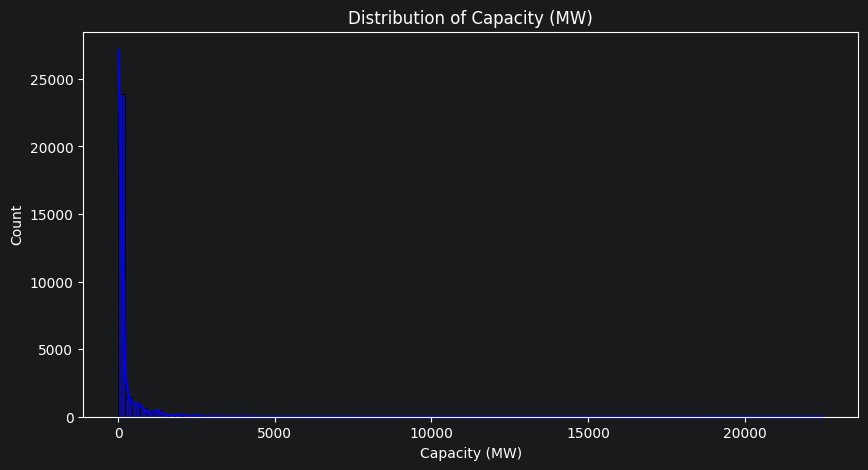

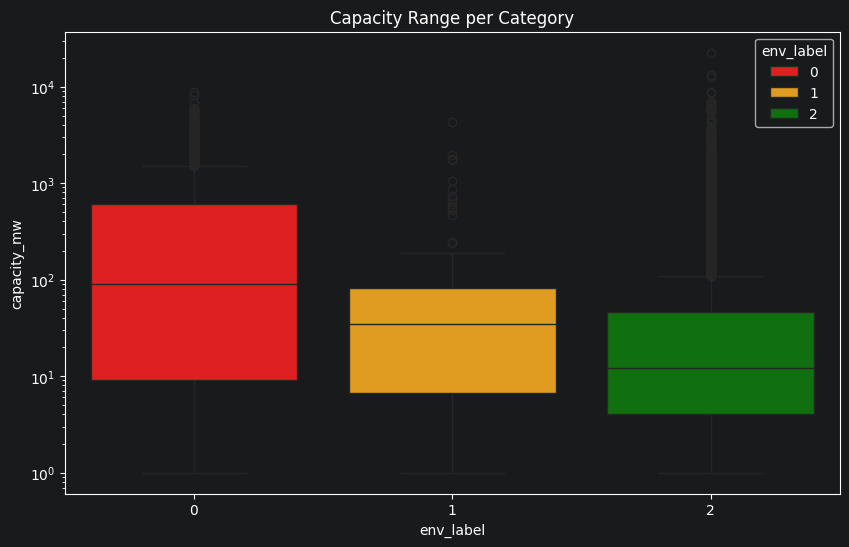

Number of Extreme Outliers: 3652

Numbers and Percentages of Outliers
                  Count  Percentage (%)
env_label                              
0: Non-Renewable   2997       82.064622
1: Hybrid            14        0.383352
2: Renewable        641       17.552026
Stats With Outliers
   env_label        mean  median         std
0          0  417.237868   90.00  708.670734
1          1  114.054081   34.45  370.221438
2          2   72.544131   12.00  350.249686 

Stats Without Extreme Outliers
   env_label       mean     median        std
0          0  69.315244  21.000000  95.553176
1          1  45.659880  31.150000  47.009197
2          2  34.145740  10.680235  56.846732 



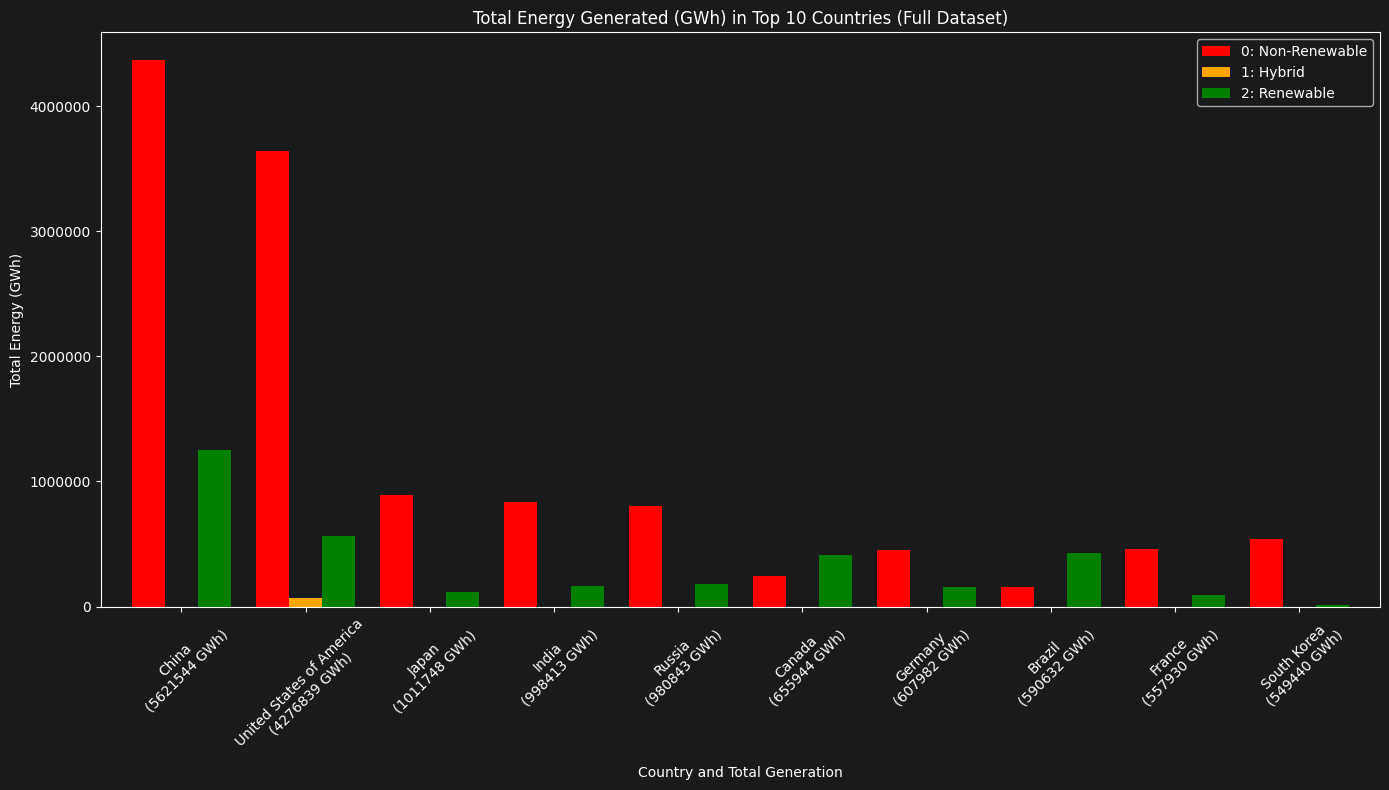

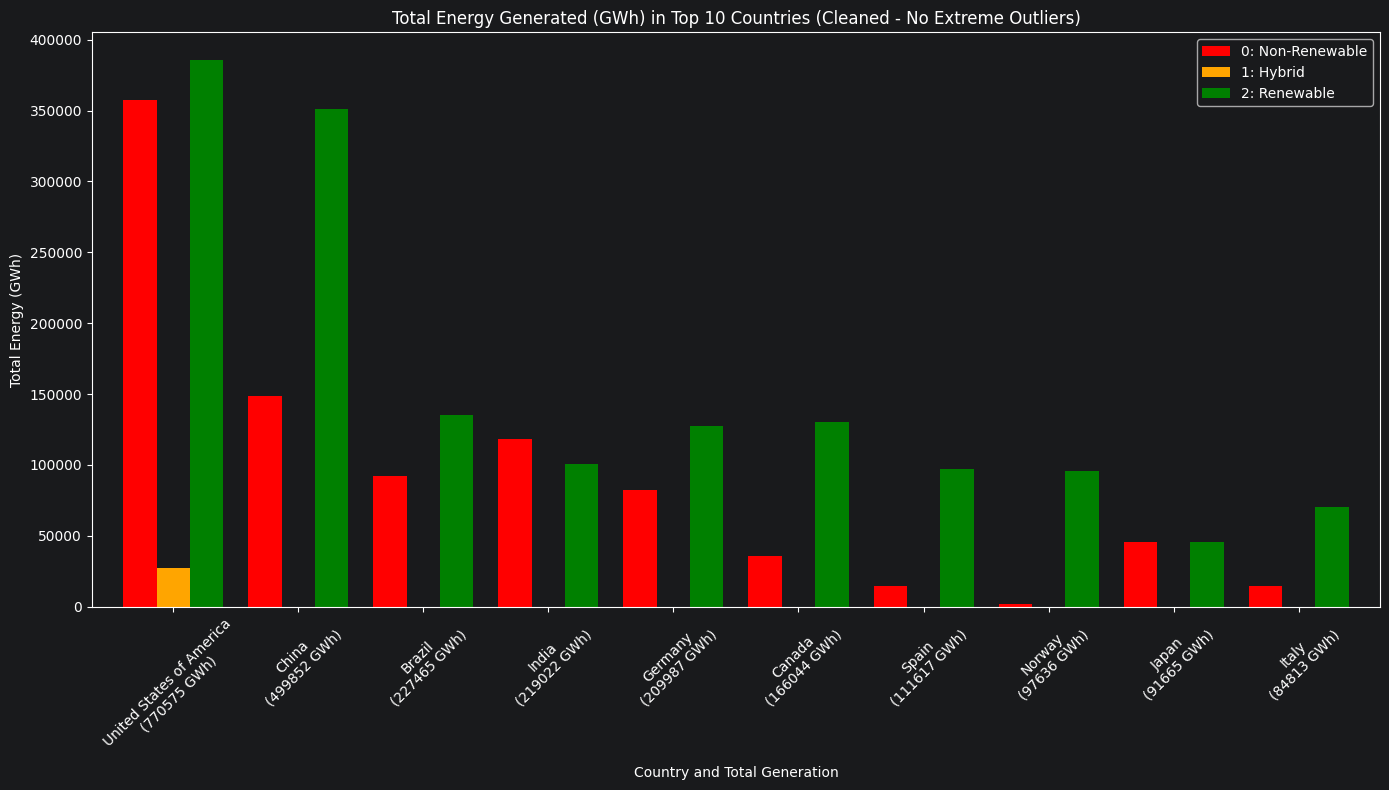

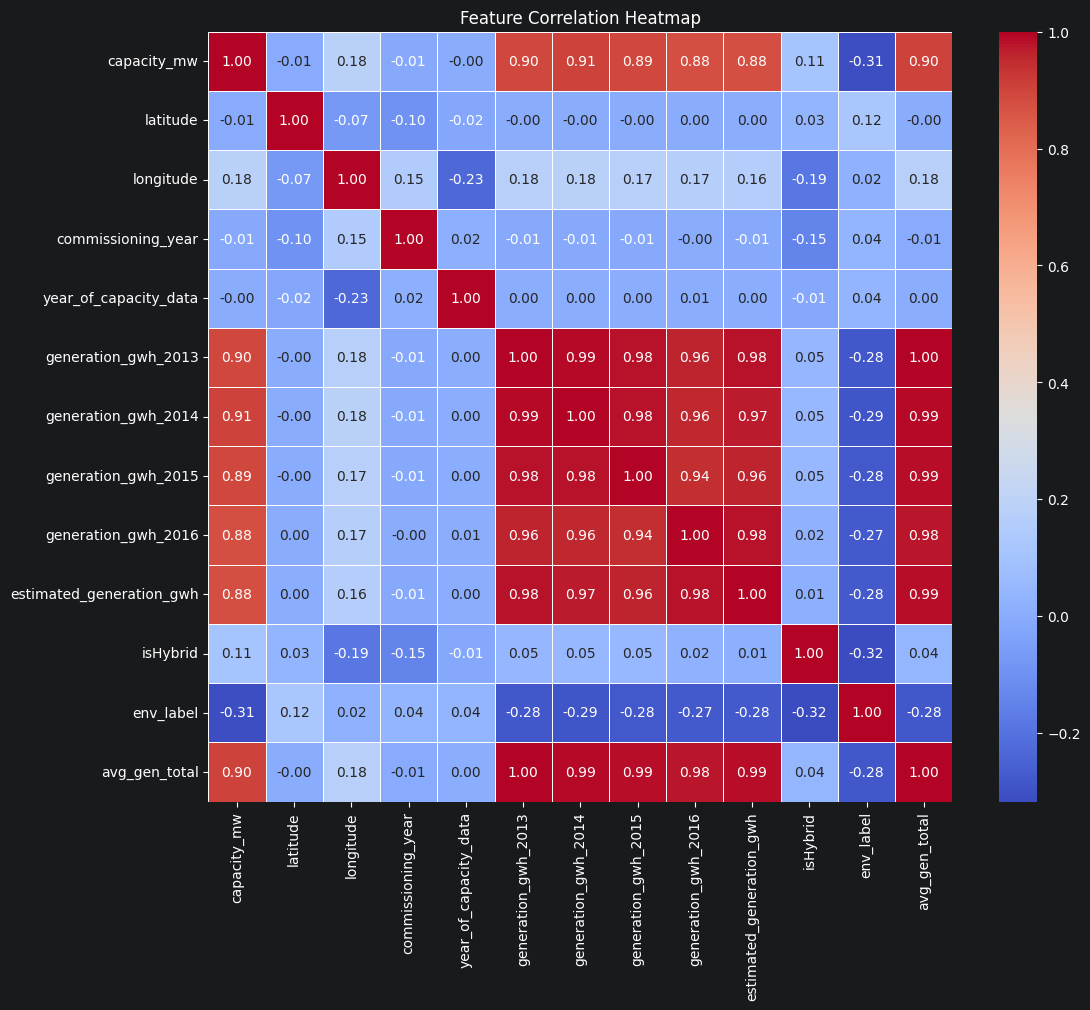

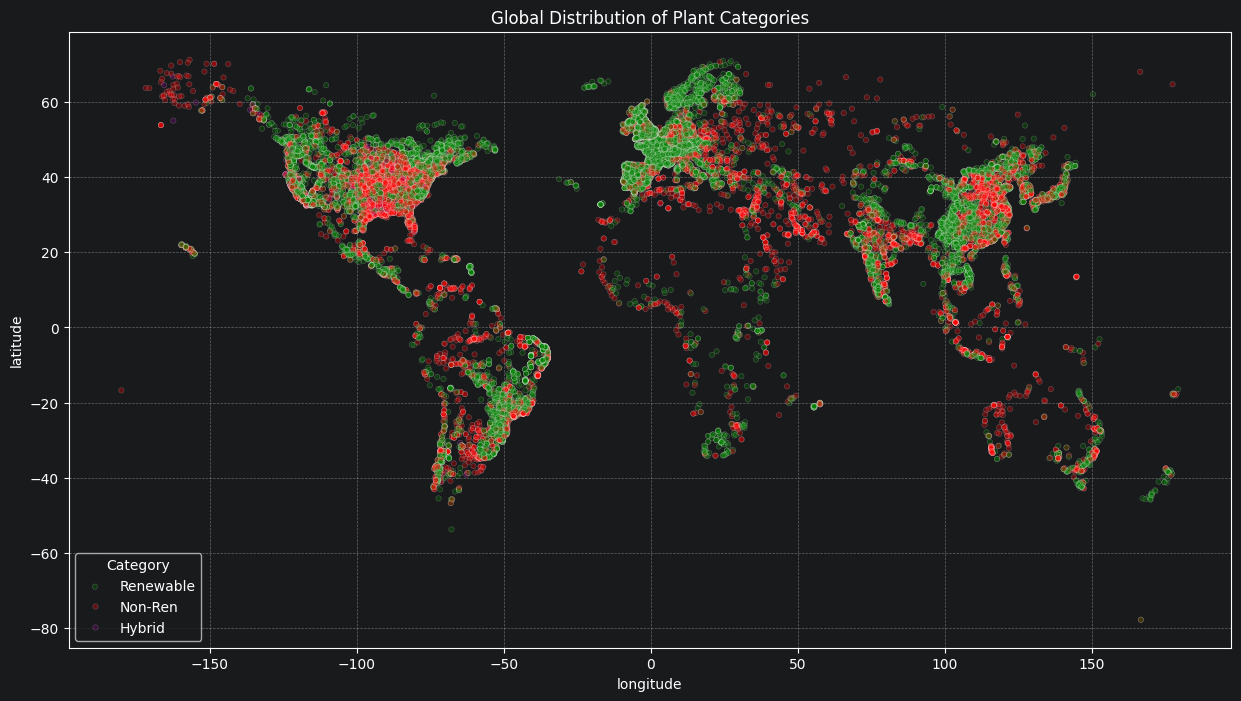

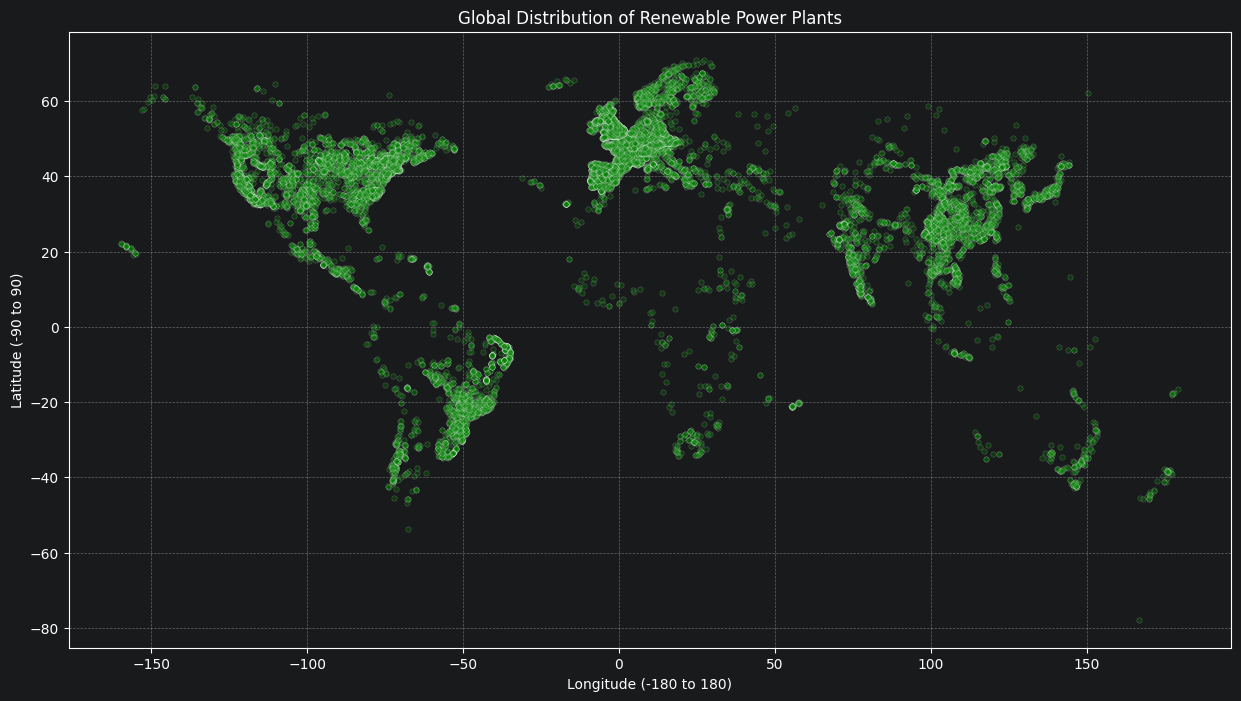

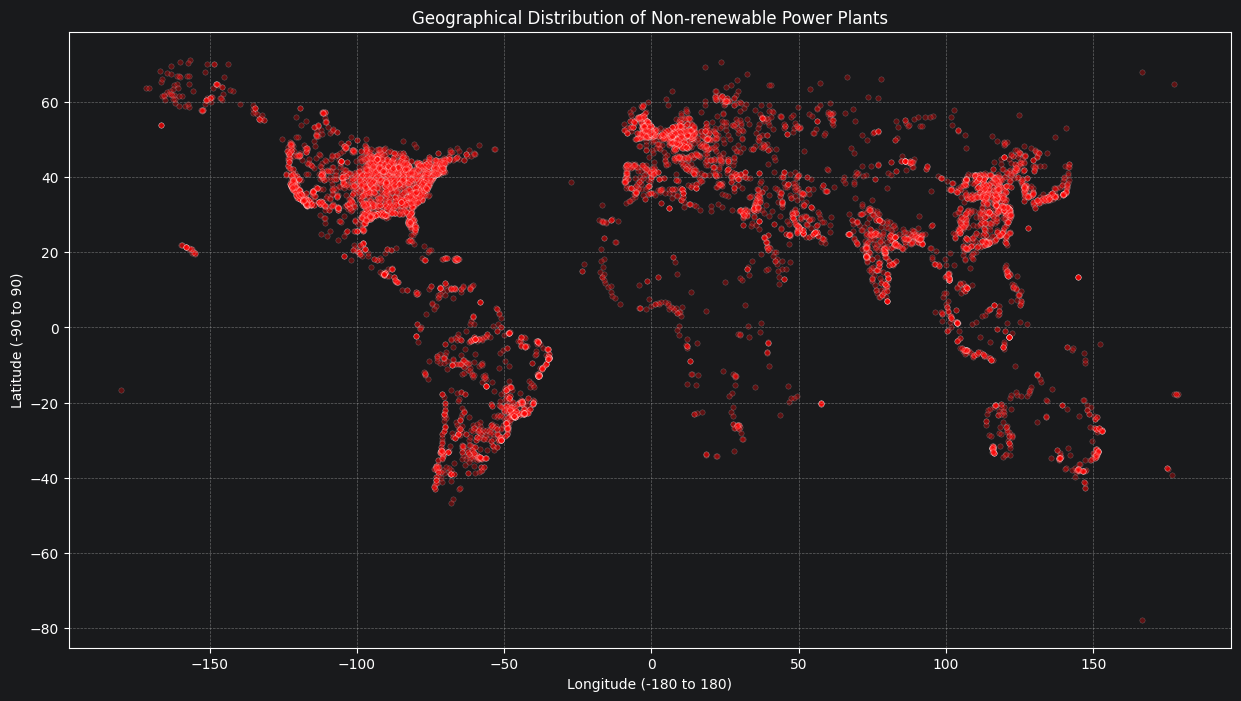

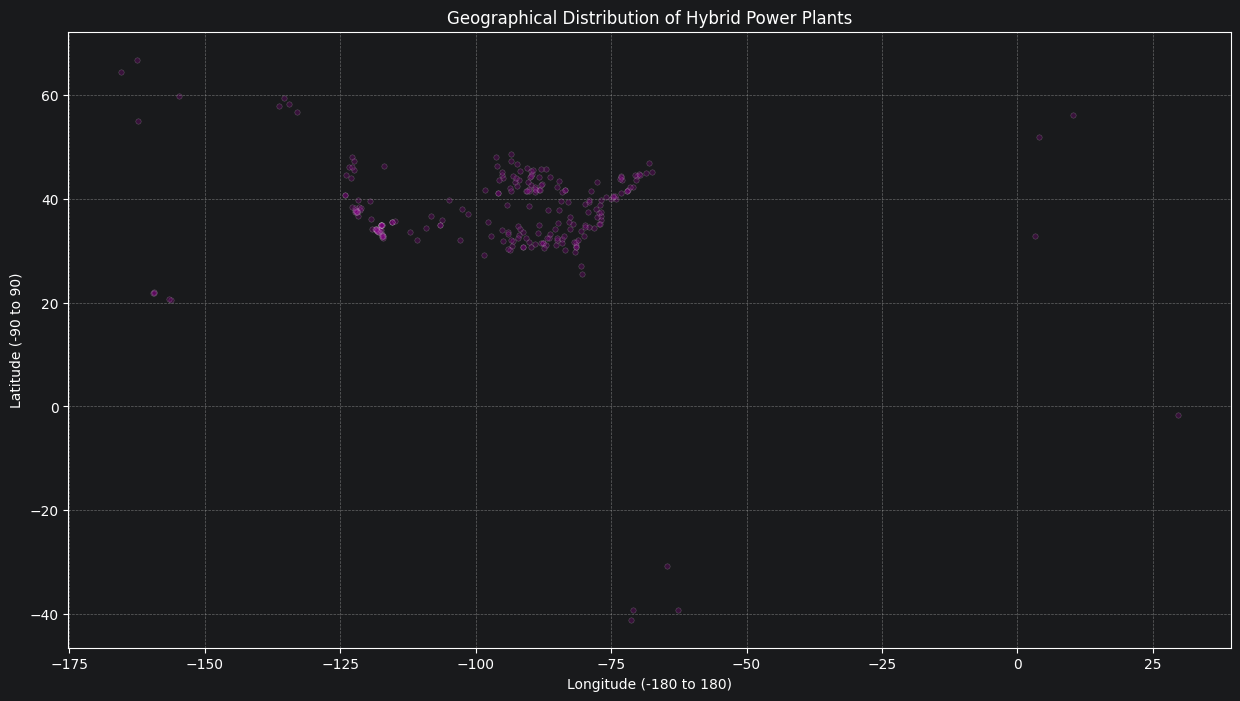

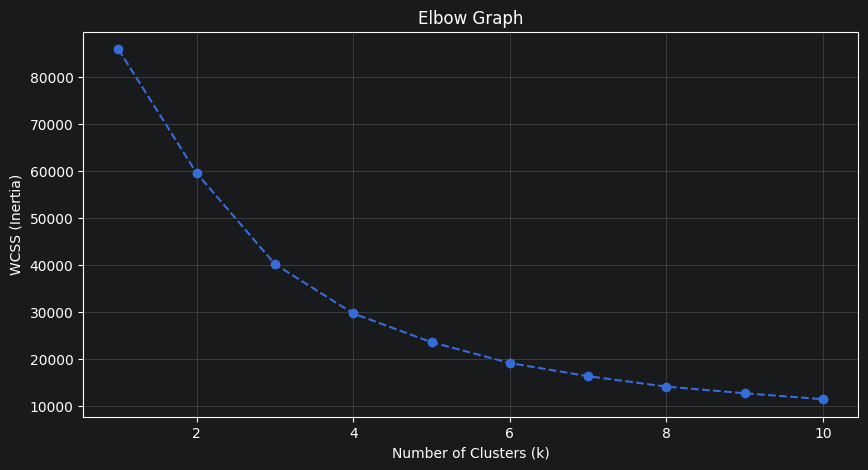

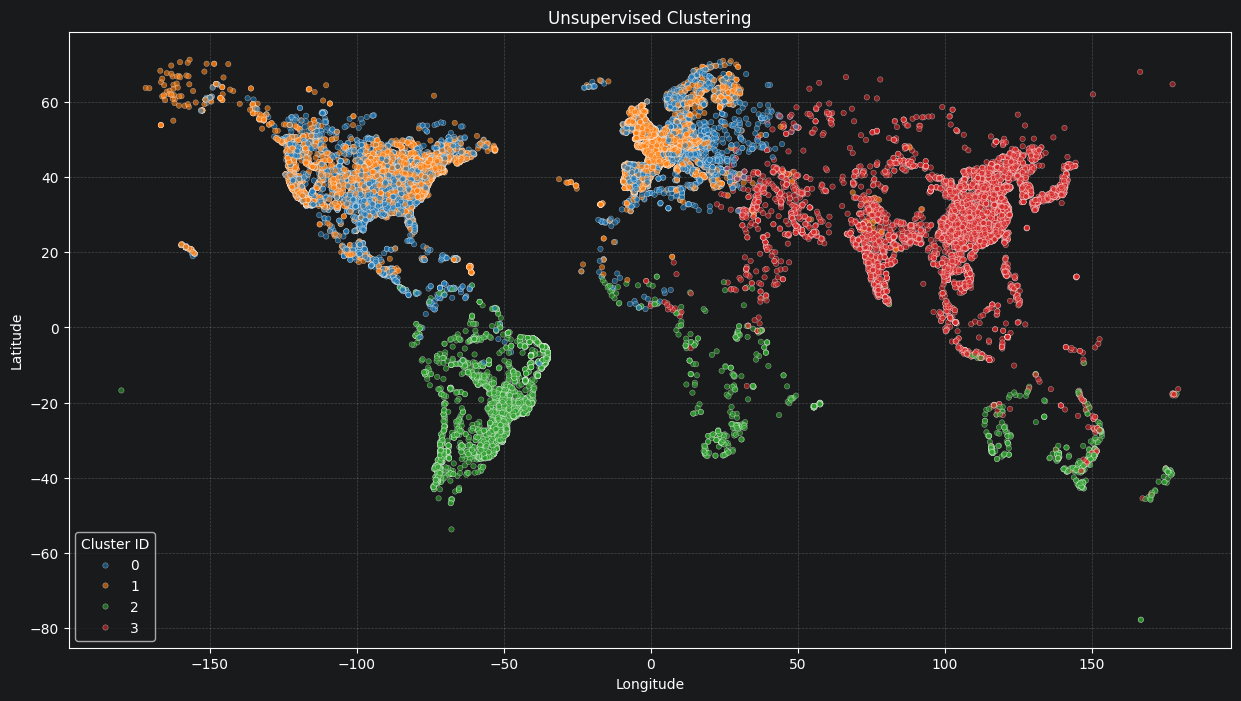

Average Characteristics of Each Natural Cluster:
             latitude   longitude  capacity_mw
cluster_id                                    
0           40.940622  -59.112687   379.628837
1           45.057319  -40.399794     8.511629
2          -21.019887  -24.853818    74.699258
3           27.972882  100.156109   438.371036
Comparison Table
                    0: Non-Renewable  1: Hybrid  2: Renewable
Machine Cluster ID                                           
0                               3101        134          2862
1                               2345        109         10392
2                               1405          5          2305
3                               2562          0          3444


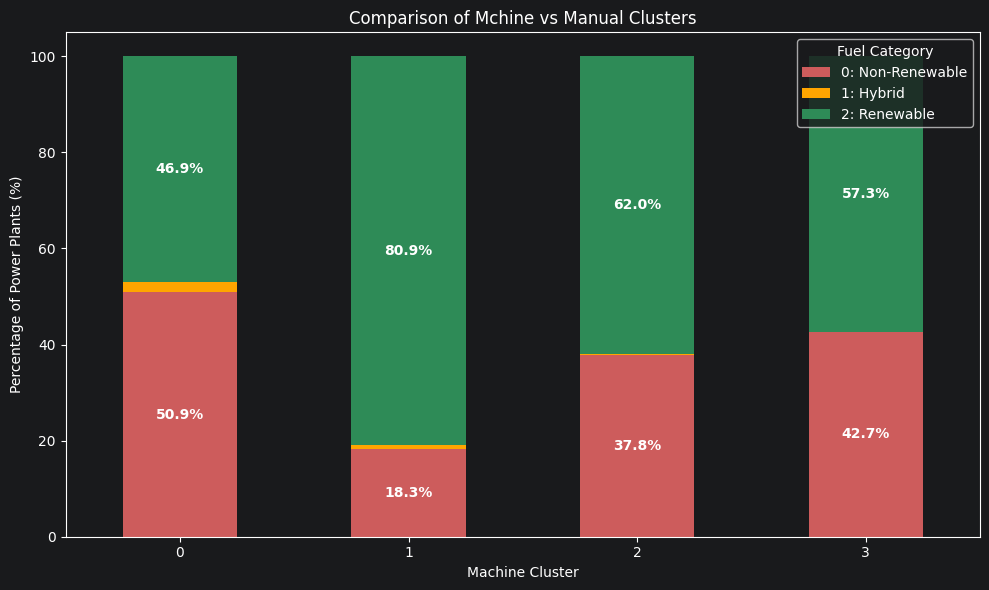

In [5]:
# DATA EXPLORATION AND ANALYSIS 

# Check Skewness
plt.figure(figsize=(10, 5))
sns.histplot(df['capacity_mw'], bins=100, kde=True, color='blue')
plt.title('Distribution of Capacity (MW)')
plt.xlabel('Capacity (MW)')
plt.show()

# Used boxplot to see any outliers in different categories
plt.figure(figsize=(10, 6))
sns.boxplot(x='env_label', y='capacity_mw', data=df, hue='env_label', palette=['red', 'orange', 'green'])
plt.yscale('log') # Log scale is necessary to see the box due to outliers
plt.title('Capacity Range per Category')
plt.show()

# Find extreme outliers
# Use 3 * IQR rule for extreme outliers
q1 = df['capacity_mw'].quantile(0.25)
q3 = df['capacity_mw'].quantile(0.75)
iqr = q3 - q1
extreme_limit = q3 + (3 * iqr)

extreme_plants = df[df['capacity_mw'] > extreme_limit]
df_clean = df[df['capacity_mw'] <= extreme_limit].copy()

# Number and percentage of outliers by their category
outlier_counts = extreme_plants['env_label'].value_counts()
outlier_percentages = (outlier_counts / len(extreme_plants)) * 100

outlier_summary = pd.DataFrame({
    'Count': outlier_counts,
    'Percentage (%)': outlier_percentages
}).sort_index()

outlier_summary.index = outlier_summary.index.map({0: '0: Non-Renewable', 1: '1: Hybrid', 2: '2: Renewable'})

print(f"Number of Extreme Outliers: {len(extreme_plants)}\n")
print("Numbers and Percentages of Outliers")
print(outlier_summary)

# Stats comparison
def get_stats(data_frame):
    return data_frame.groupby('env_label')['capacity_mw'].agg(['mean', 'median', 'std']).reset_index()

print("Stats With Outliers")
print(get_stats(df), "\n")

print("Stats Without Extreme Outliers")
print(get_stats(df_clean), "\n")

# Top 10 Countries by their total energy generations
def plot_final_energy_charts(data, title_suffix):
    # Calculate the total energy generated for each country and sort them in descending order
    country_totals = data.groupby('country_long')['avg_gen_total'].sum().sort_values(ascending=False).head(10)
    top_10_names = country_totals.index
    
    # Take top 10 countries
    subset = data[data['country_long'].isin(top_10_names)]
    
    energy_pivot = subset.pivot_table(index='country_long', columns='env_label', values='avg_gen_total', aggfunc='sum', fill_value=0)
    energy_pivot = energy_pivot.reindex(top_10_names) # Reindex to maintain the descending order on the x-axis
    
    # Plotting
    ax = energy_pivot.plot(kind='bar', figsize=(14, 8), width=0.8, color=['red', 'orange', 'green'])
    
    new_labels = [f"{name}\n({country_totals[name]:.0f} GWh)" for name in top_10_names]
    ax.set_xticklabels(new_labels, rotation=45)
    ax.ticklabel_format(style='plain', axis='y') # Get rid of scientific notations
    
    plt.title(f'Total Energy Generated (GWh) in Top 10 Countries {title_suffix}')
    plt.xlabel('Country and Total Generation')
    plt.ylabel('Total Energy (GWh)')
    plt.legend(['0: Non-Renewable', '1: Hybrid', '2: Renewable'])
    plt.tight_layout()
    plt.show()

# Plot the graphs for both datasets
plot_final_energy_charts(df, "(Full Dataset)")
plot_final_energy_charts(df_clean, "(Cleaned - No Extreme Outliers)")


# CORRELATION HEATMAP
plt.figure(figsize=(12, 10))

numeric_cols = df.select_dtypes(include=[np.number]) # Select only the numeric columns for correlation
corr_matrix = numeric_cols.corr()

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Heatmap')
plt.show()

# GEOGRAPHICAL MAPS 
# All together
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='env_label', palette=['red', 'purple', 'green'], alpha=0.3, s=15)
plt.title('Global Distribution of Plant Categories')
plt.legend(title='Category', labels=['Renewable', 'Non-Ren', 'Hybrid'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Renewables only
renewable_df = df[df['env_label'] == 2].copy()

plt.figure(figsize=(15, 8))
sns.scatterplot(data=renewable_df, x='longitude', y='latitude', color='green', alpha=0.3, s=15)

plt.title('Global Distribution of Renewable Power Plants')
plt.xlabel('Longitude (-180 to 180)')
plt.ylabel('Latitude (-90 to 90)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Non-renewables only
renewable_plants = df[df['env_label'] == 0].copy()

plt.figure(figsize=(15, 8))
sns.scatterplot(data=renewable_plants, x='longitude', y='latitude', color='red', alpha=0.3, s=15)

plt.title('Geographical Distribution of Non-renewable Power Plants')
plt.xlabel('Longitude (-180 to 180)')
plt.ylabel('Latitude (-90 to 90)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Hybrids only
renewable_plants = df[df['env_label'] == 1].copy()

plt.figure(figsize=(15, 8))
sns.scatterplot(data=renewable_plants, x='longitude', y='latitude', color='purple', alpha=0.3, s=15)

plt.title('Geographical Distribution of Hybrid Power Plants')
plt.xlabel('Longitude (-180 to 180)')
plt.ylabel('Latitude (-90 to 90)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# K-MEANS CLUSTERING

# Preprocess for clustering
# I used log transformation so extreme outliers don't mess Euclidean distance
df['capacity_log'] = np.log1p(df['capacity_mw']) # np.log1p handles 0 values safely

# Select features
cluster_features = ['latitude', 'longitude', 'capacity_log']
X = df[cluster_features]

# Scaling is needed for K-Means to treat Location and Size equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Graph')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.3)
plt.show()

# K-means execution
k_optimal = 4 # Based on elbow method
kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df['cluster_id'] = kmeans_final.fit_predict(X_scaled)

# Check clusters on map
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='cluster_id', palette='tab10', s=15, alpha=0.6)

plt.title('Unsupervised Clustering')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Summary 
print("Average Characteristics of Each Natural Cluster:")
cluster_summary = df.groupby('cluster_id')[['latitude', 'longitude', 'capacity_mw']].mean()
print(cluster_summary)

# COMPARISON OF MACHINE vs MANUAL CLUSTERS
# Create a Crosstab 
comparison_table = pd.crosstab(df['cluster_id'], df['env_label'])
comparison_table.columns = ['0: Non-Renewable', '1: Hybrid', '2: Renewable']
comparison_table.index.name = 'Machine Cluster ID'

print("Comparison Table")
print(comparison_table)

comparison_pct = comparison_table.div(comparison_table.sum(axis=1), axis=0) * 100 # Convert to percentages 

# Plot the Comparison
ax = comparison_pct.plot(kind='bar', stacked=True, figsize=(10, 6), 
                         color=['indianred', 'orange', 'seagreen'])

plt.title('Comparison of Mchine vs Manual Clusters')
plt.xlabel('Machine Cluster')
plt.ylabel('Percentage of Power Plants (%)')
plt.legend(title='Fuel Category')
plt.xticks(rotation=0)

# Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Only show labels for bars larger than 5%
        x, y = p.get_xy() 
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

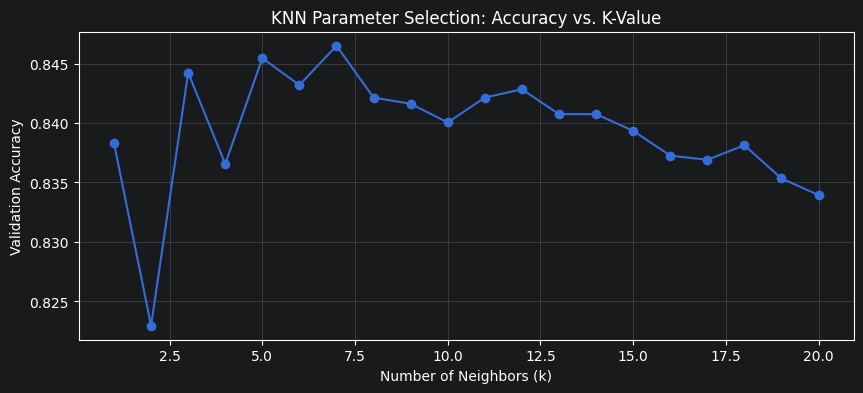

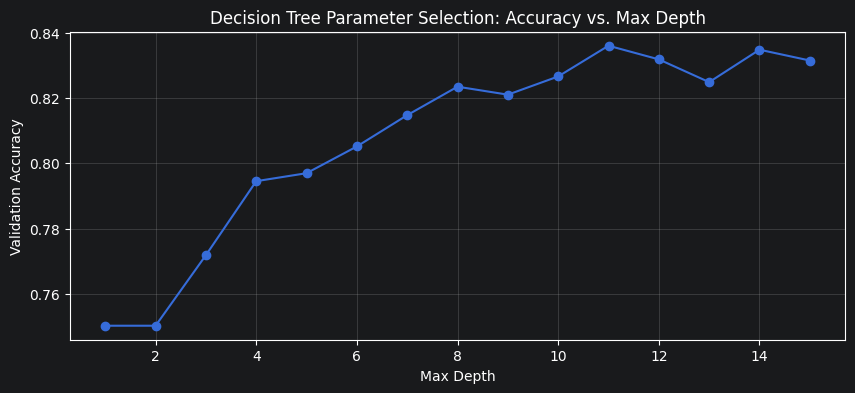

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",11
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [6]:
# PREDICTIVE MODELLING

# Filling missing values
df['commissioning_year'] = df['commissioning_year'].fillna(df['commissioning_year'].median())

# Feature Selection
features = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year']
X = df[features]
y = df['env_label']

# Splitting Data (60% Train, 20% Validation, 20% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Scaling (Needed for Logistic Regression and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# LOGISTIC REGRESSION
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_val_acc = accuracy_score(y_val, lr_model.predict(X_val_scaled))

# K-NEAREST NEIGHBORS
k_range = range(1, 21)
knn_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = accuracy_score(y_val, knn.predict(X_val_scaled))
    knn_accuracies.append(score)

# Visualizing Parameter Selection for KNN
plt.figure(figsize=(10, 4))
plt.plot(k_range, knn_accuracies, marker='o')
plt.title('KNN Parameter Selection: Accuracy vs. K-Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_range[np.argmax(knn_accuracies)]
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# DECISION TREE
depth_range = range(1, 16)
dt_accuracies = []

for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    score = accuracy_score(y_val, dt.predict(X_val))
    dt_accuracies.append(score)

# Visualizing Parameter Selection for Decision Tree
plt.figure(figsize=(10, 4))
plt.plot(depth_range, dt_accuracies, marker='o')
plt.title('Decision Tree Parameter Selection: Accuracy vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

best_depth = depth_range[np.argmax(dt_accuracies)]
final_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_dt.fit(X_train, y_train)

FINAL TEST SET PERFORMANCE SUMMARY:

 Model: Logistic Regression
              precision    recall  f1-score   support

 Non-Ren (0)       0.81      0.27      0.41      1887
  Hybrid (1)       0.00      0.00      0.00        40
     Ren (2)       0.72      0.97      0.83      3806

    accuracy                           0.73      5733
   macro avg       0.51      0.41      0.41      5733
weighted avg       0.75      0.73      0.68      5733


 Model: KNN (k=7)
              precision    recall  f1-score   support

 Non-Ren (0)       0.79      0.75      0.77      1887
  Hybrid (1)       0.00      0.00      0.00        40
     Ren (2)       0.88      0.91      0.89      3806

    accuracy                           0.85      5733
   macro avg       0.56      0.55      0.55      5733
weighted avg       0.84      0.85      0.84      5733


 Model: Decision Tree (depth=11)
              precision    recall  f1-score   support

 Non-Ren (0)       0.78      0.73      0.75      1887
  Hybrid (1

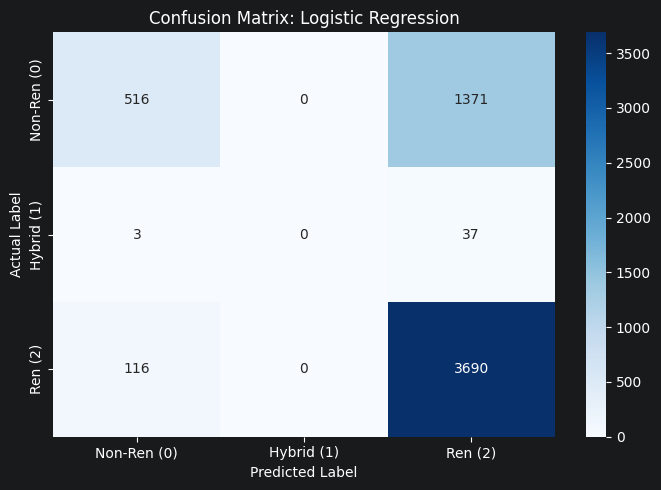

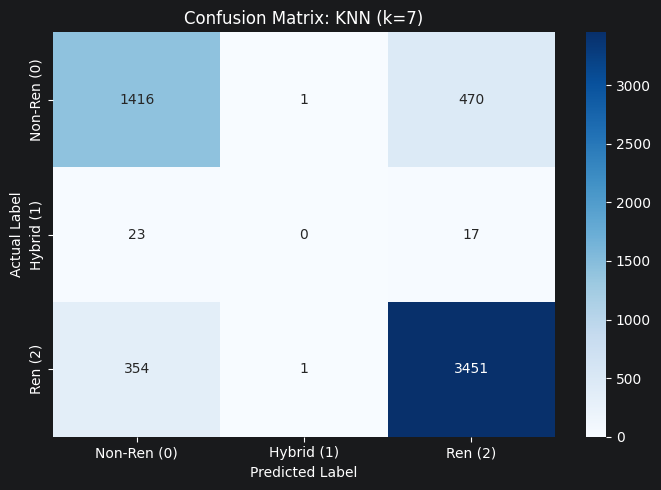

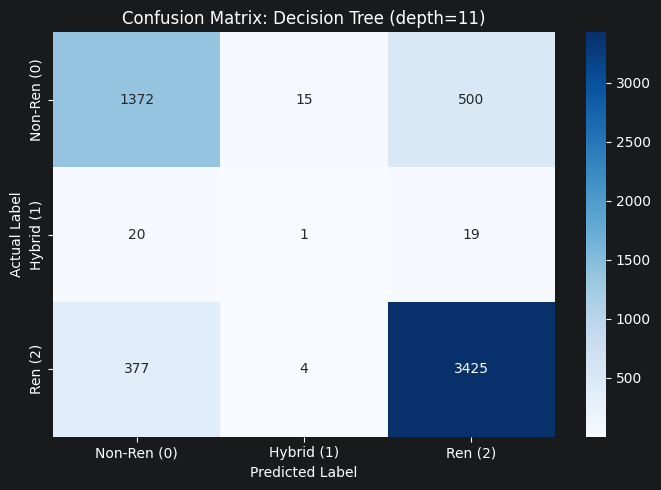

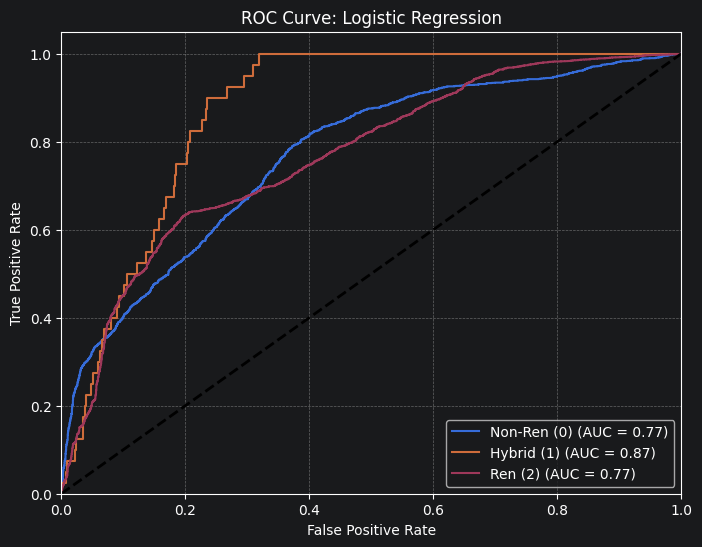

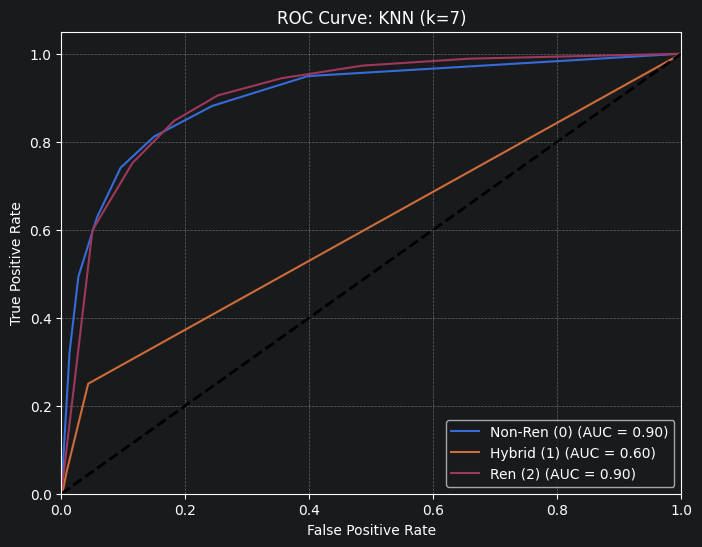

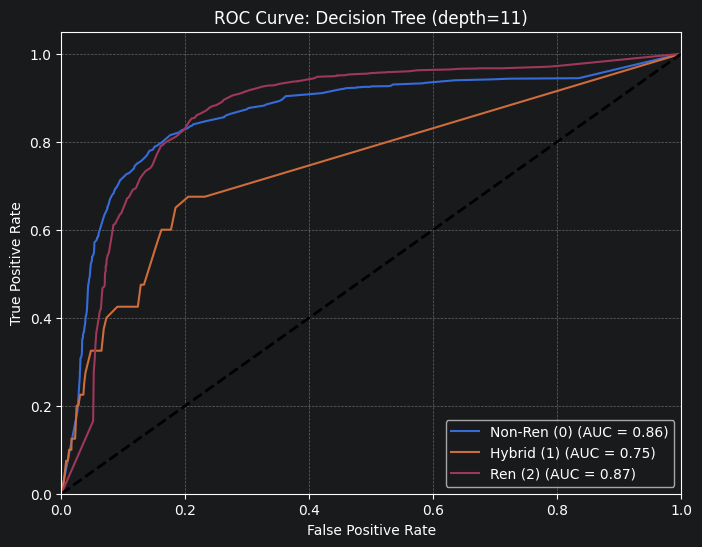

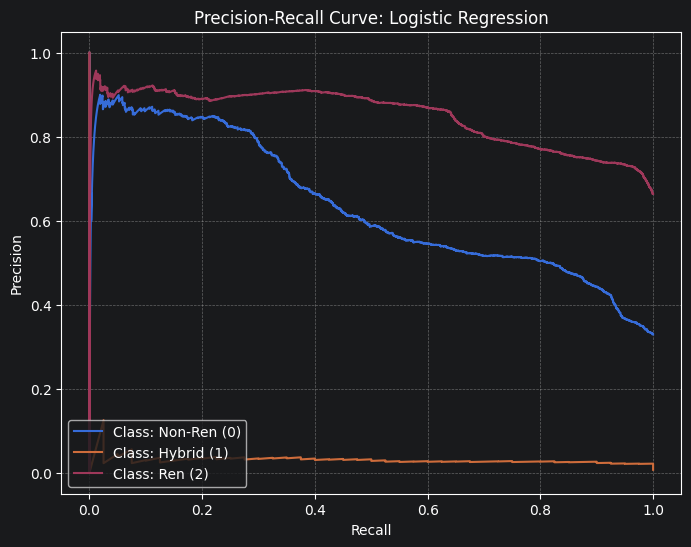

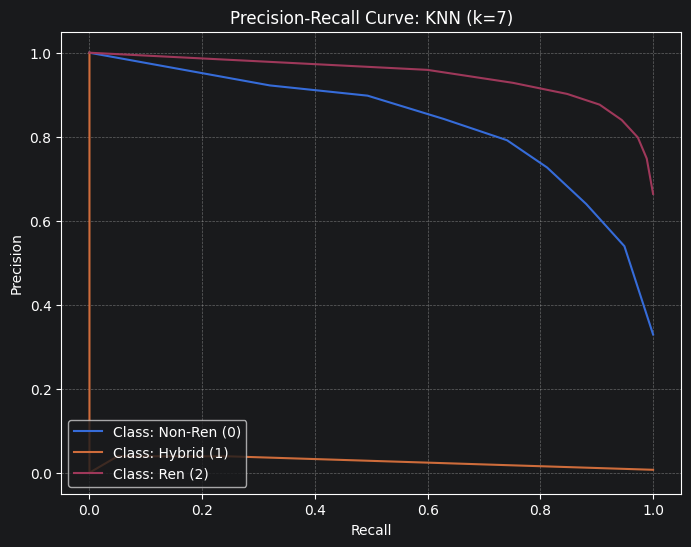

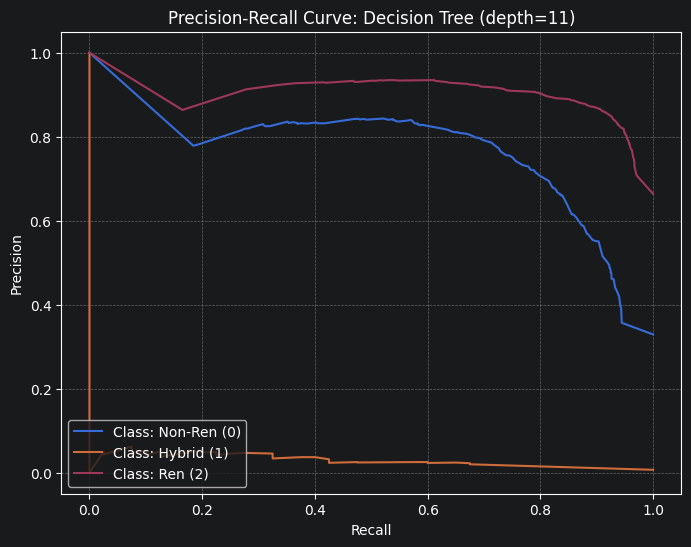

In [7]:
# MODEL EVALUATION

labels = ['Non-Ren (0)', 'Hybrid (1)', 'Ren (2)']
y_test_bin = label_binarize(y_test, classes=[0, 1, 2]) # Binarize target labels for multi-class ROC and PR curve plotting
n_classes = y_test_bin.shape[1]

models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "KNN (k={})".format(best_k): (final_knn, X_test_scaled),
    "Decision Tree (depth={})".format(best_depth): (final_dt, X_test)
}

# Final Performance Summary
print("FINAL TEST SET PERFORMANCE SUMMARY:")
for name, (model, data) in models.items():
    y_pred = model.predict(data)
    print(f"\n Model: {name}")
    print(classification_report(y_test, y_pred, target_names=labels, zero_division=0)) # Precision, Recall, and F1-Score

# Confusion Matrices
for name, (model, data) in models.items():
    plt.figure(figsize=(7, 5))
    y_pred = model.predict(data)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# ROC CURVES
# Measures the trade-off between TP and FP rates per class
for name, (model, data) in models.items():
    # Obtain probability scores for each class
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(data)
    else:
        y_score = model.decision_function(data)

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{labels[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name}')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# PR CURVES
# Critical for imbalanced datasets; shows the model's ability to find all relevant cases
for name, (model, data) in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(data)
    else:
        y_score = model.decision_function(data)

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        plt.plot(recall, precision, label=f'Class: {labels[i]}')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {name}')
    plt.legend(loc="lower left")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [8]:
# PROJECT REPORT
'''
DATA EXPLORATION AND ANALYSIS  

-> I checked the skewness of data and found it is extremely right-skewed. Which indicates outliers.

-> Then I checked outliers of different env_label data and found both renewable and non-renewable plants have outliers.

-> After that I dropped extreme outliers from total data and find out 82% of it is non-renewable plants.
Also after dropping the outliers, mean of non-renewable plants highly decreased and became close to renewable and hybrid plants.
From these, we can say that even though there are some huge non-renewable plants, 
in average plant renewable one can compensate the non-renewable one in long run.

-> Then I compared Total Energy Generated in top 10 countries with and without the outliers. 
The result is these outliers are very important part of the total energies in top countries. 
In fact some countries even dropped out of the top 10 list after the removal of outliers. 
Also I should mention that hybrid plants are noticeable only in USA out of all top 10 countries.
Which may be caused by the encouraging policies taken by government about the transition from non-renewable to renewable resources.

-> Then I checked the correlation heatmap for any hidden correlations and i find out latitude and energy creation slightly related.
So I decided to check distribution of plants in world map. I decided to include outliers in these distribution graphs
because these outliers are not errors, they are real data's with meaning.
I found out from these graphs that Europe is the only continent where renewable plants are superior to non-renewable ones.
Also Hybrid plants located longitudes between (-125 to -60) which confirms our inference about USA.

-> Then I used K-Means for unlabeled clustering. I found out 4 cluster is optimal from elbow method.
Compared these clusters with previous ones(manuel clusters). Only the Cluster 1 seems to be coherent due to being consist of 80.9% renewable plants.


PREDICTIVE MODELLING

-> In this part, I split the data to 3 part(60% Train, 20% Validation, 20% Test) and then do necessary scalings. 
I used 3 different classification algorithms(Logistic Regression, KNN, Decision Tree). 
I plot a graph for different number of neighbors and max depth to find out the best. I found K=7 and max depth =11.


MODEL EVALUATION

-> In this part, I checked performances of 3 different algorithm that I used. 

-> Logistic Regression:
This is your weakest performer. It is heavily biased towards the majority class (Ren).
A recall of 0.27 for "Non-Ren" means it is missing nearly 75% of non-renewable plants, misclassifying them as renewable.
It fails completely on the Hybrid class.

-> KNN (k=7):
KNN shows a significant jump in performance. It is much better at distinguishing between Non-Renewable and Renewable plants,
with F1-scores of 0.77 and 0.89 respectively. It has the highest overall accuracy, but it still fails to identify a single Hybrid plant.

-> Decision Tree (depth=11):
The Decision Tree is the only model that managed to catch at least one Hybrid plant (indicated by the 0.05 precision and 0.03 recall),
though it's still struggling. Its performance on the other two classes is nearly as good as KNN.

-> ROC Analysis: My AUC scores for Classes 0 and 2 were consistently high (approaching 0.90+), 
which means the models have a 90% chance of correctly distinguishing a Renewable plant from a Non-Renewable one.

->PR Analysis: I included Precision-Recall curves because my classes are imbalanced (there are fewer Hybrids).
The PR curves showed me that while my models are accurate overall, their precision drops when they try to find the rare Hybrid plants.

'''

'\nDATA EXPLORATION AND ANALYSIS  \n\n-> I checked the skewness of data and found it is extremely right-skewed. Which indicates outliers.\n\n-> Then I checked outliers of different env_label data and found both renewable and non-renewable plants have outliers.\n\n-> After that I dropped extreme outliers from total data and find out 82% of it is non-renewable plants.\nAlso after dropping the outliers, mean of non-renewable plants highly decreased and became close to renewable and hybrid plants.\nFrom these, we can say that even though there are some huge non-renewable plants, \nin average plant renewable one can compensate the non-renewable one in long run.\n\n-> Then I compared Total Energy Generated in top 10 countries with and without the outliers. \nThe result is these outliers are very important part of the total energies in top countries. \nIn fact some countries even dropped out of the top 10 list after the removal of outliers. \nAlso I should mention that hybrid plants are notic